In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

# Ensure the notebook can find the /src directory
root_path = Path.cwd().parent
if str(root_path) not in sys.path:
    sys.path.append(str(root_path))

In [2]:
from src.data_loader import VesselDataLoader
from src.data_processing import DataProcessor
from src.feature_evaluation import FeatureEvaluator

In [3]:
# Path to your raw telemetry
raw_data_file1 = root_path / "data" / "raw" / "Rotherhithe_voy_179.csv"
raw_data_file2 = root_path / "data" / "raw" / "Wembley_voy_236.csv"

# Instantiate
loader1 = VesselDataLoader(raw_data_file1)
loader2 = VesselDataLoader(raw_data_file2)

# Load and clean the data
baseline_df1 = loader1.load_and_clean()
baseline_df2 = loader2.load_and_clean()



In [14]:
experiments = [
    # {"name": "Raw_Baseline", "method": "raw", "params": {}},
    # {"name": "Savgol_Smooth_W5_P2", "method": "savgol", "params": {"window": 5, "polyorder": 2}},
    # {"name": "Savgol_Aggressive_W11_P2", "method": "savgol", "params": {"window": 11, "polyorder": 2}},
    # {"name": "Butterworth_LowPass_C01", "method": "butter", "params": {"cutoff": 0.1, "order": 2}},
    {"name": "Butterworth_Aggressive_C005", "method": "butter", "params": {"cutoff": 0.05, "order": 2}},
]

base_features = ['AE_POWER(kW)', 'NUM_GENERATORS']
engineered_features = ['GEN_TRANSITION', 'ROT_DEG_PER_MIN', 'ENERGY_INTENSITY', 'POWER_TV_ENERGY', 'PF_DERIVATIVE', 'MANEUVER_INTENSITY']
all_features = base_features + engineered_features

results_archive = {}


>>> Running Experiment: Butterworth_Aggressive_C005 ...
Diagnostics for Butterworth_Aggressive_C005:


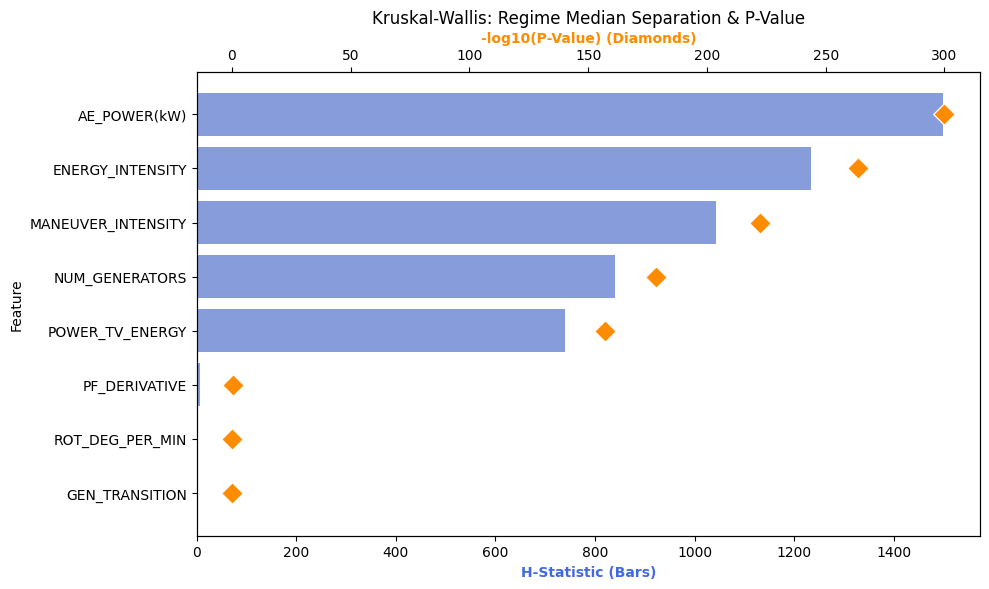

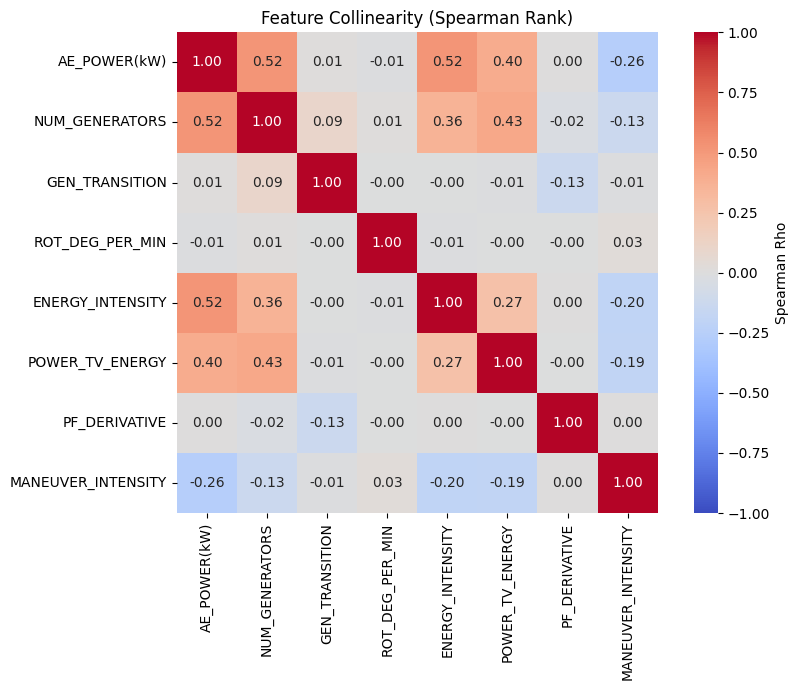

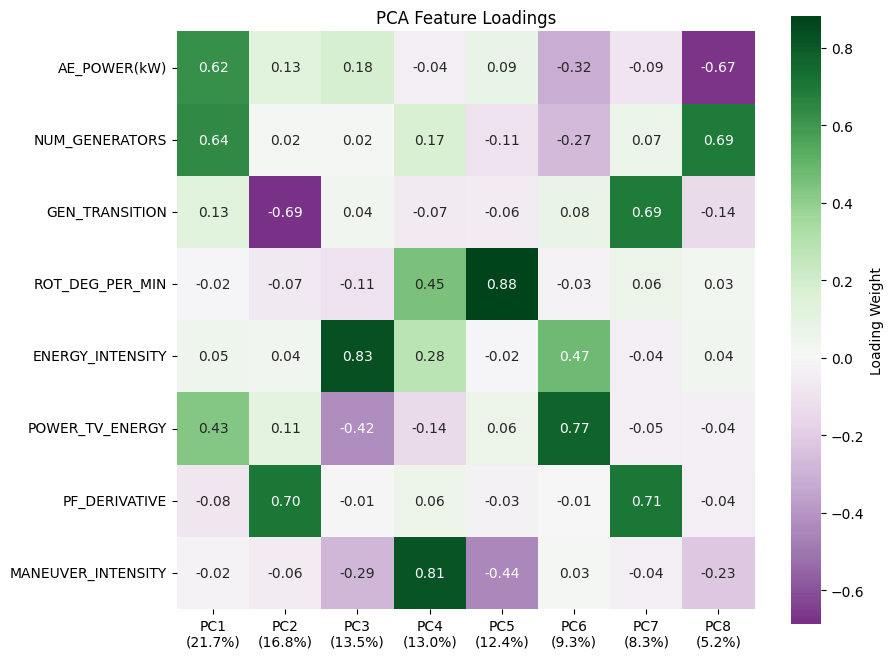

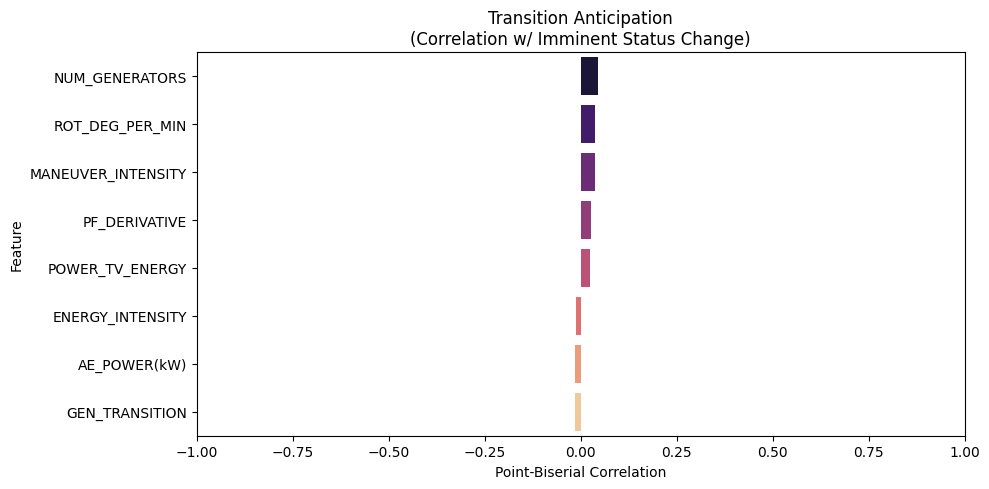

# MARINER Feature Evaluation Report

## 1. Statistical Divergence (Kruskal-Wallis H-Test)
*(Higher H-Statistic indicates stronger median separation. Low P-Value indicates statistical significance.)*
| Feature            |   H-Statistic |   P-Value |
|:-------------------|--------------:|----------:|
| AE_POWER(kW)       |      1498.15  | 0         |
| ENERGY_INTENSITY   |      1232.98  | 2.11e-264 |
| MANEUVER_INTENSITY |      1042.93  | 3.05e-223 |
| NUM_GENERATORS     |       840.397 | 2.1e-179  |
| POWER_TV_ENERGY    |       739.852 | 1.18e-157 |
| PF_DERIVATIVE      |         6.604 | 0.252     |
| ROT_DEG_PER_MIN    |         3.641 | 0.602     |
| GEN_TRANSITION     |         2.227 | 0.817     |


## 2. Feature Collinearity (Spearman Rank Correlation)
*(Values > 0.75 or < -0.75 indicate highly redundant physical information)*
| Feature 1        | Feature 2    |   Spearman Rho |
|:-----------------|:-------------|---------------:|
| ENERGY_INTENSITY | AE_POWER(kW) |       0.520627 |

In [ ]:
for exp in experiments:
    print(f"\n>>> Running Experiment: {exp['name']} ...")

    # Process
    processor = DataProcessor(baseline_df1)
    processed_df = processor.extract_features_and_filter(
        filter_method=exp['method'], 
        **exp['params']
    )
    
    # Evaluate
    evaluator = FeatureEvaluator(processed_df, target_col='STATUS')
    evaluation = evaluator.evaluate(all_features, strategy='all')

    # Store for cross-comparison
    results_archive[exp['name']] = {
        "report": evaluator.generate_markdown_report(evaluation),
        "eval_obj": evaluation,
        "evaluator": evaluator
    }
    
    # Immediate Visualization
    print(f"Diagnostics for {exp['name']}:")
    evaluator.plot_diagnostics(evaluation)
    print(evaluator.generate_markdown_report(evaluation))